
## **Tackling CIFAR-10 With a DNN/CNN**





In this work, you need to modify the colab file to complete the CIFAR-10 task with a CNN. Please submit the completed colab file to Canvas (PRMLS Day 2 workshop submission).

Moreover, what kind(s) of setup/configuration does the colab training recipe use (not found in our lecturer slides) so that we can rapidly complete model training?

Please provide your answer below:

**[Answer here]**

---



# 0. Set CPU threading before importing TensorFlow

In [2]:
# ---- MUST run before importing tensorflow ----
import os

# from sympy.printing.tensorflow import tensorflow

# Pin TF to the 4 vCPUs allocated by your batch job
os.environ["OMP_NUM_THREADS"] = "4"            # OpenMP threads for oneDNN/MKL
os.environ["TF_NUM_INTRAOP_THREADS"] = "4"     # parallelism inside a single op (e.g., conv matmul)
os.environ["TF_NUM_INTEROP_THREADS"] = "1"     # parallelism across independent ops; keep low on 4 cores

# Enable oneDNN CPU kernels (normally default in recent TF, safe to set)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1"

# Optional: make thread scheduling snappier on shared CPUs
os.environ["KMP_BLOCKTIME"] = "0"              # don't hold threads after finishing a block; return threads to pool promptly
os.environ["KMP_AFFINITY"]  = "granularity=fine,compact,1,0" # core affinity hints

In [4]:
import tensorflow as tf
import multiprocessing as mp, os

# Print what TF sees
print("TF version:", tf.__version__)
print("Visible CPUs (python):", mp.cpu_count())
# On Linux, this shows the cores your process may use (cgroups/cpuset)
if hasattr(os, "sched_getaffinity"):
    print("CPUs in affinity mask:", len(os.sched_getaffinity(0)))

# Apply TF runtime thread limits (mirrors env vars; optional but explicit)
tf.config.threading.set_intra_op_parallelism_threads(4) # mirror env in runtime, 4 here since have requested 4 cpus on hpc
tf.config.threading.set_inter_op_parallelism_threads(1)

# Optional: JIT/XLA may help on CPU for some graphs; try on/off
tf.config.optimizer.set_jit(False)

TF version: 2.18.0
Visible CPUs (python): 96
CPUs in affinity mask: 16


RuntimeError: Intra op parallelism cannot be modified after initialization.

# Old

## **1. Import libraries**



In [1]:
# Python ≥3.5 is asserted
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is asserted
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is asserted
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import matplotlib
import sklearn
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
# import tensorflow as tf

from tensorflow import __version__ as tf_version
from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger,LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import optimizers

print("Versions of key libraries")
print("---")
print("tensorflow: ", tf_version)
print("numpy:      ", np.__version__)
print("matplotlib: ", matplotlib.__version__)
print("sklearn:    ", sklearn.__version__)

No GPU was detected. CNNs can be very slow without a GPU.
Versions of key libraries
---
tensorflow:  2.18.0
numpy:       2.3.3
matplotlib:  3.10.6
sklearn:     1.7.2


## **2. Matplotlib setup**

In [2]:
plt.style.use('ggplot')
plt.rcParams['ytick.right']	= True
plt.rcParams['ytick.labelright']=	True
plt.rcParams['ytick.left']	= False
plt.rcParams['ytick.labelleft'] = False
# plt.rcParams['font.family']	= 'Arial'

## **3. Data preparation**



In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# The following lines are incorrect for CNN input and will be removed
# X_train = X_train[..., np.newaxis]
# X_valid = X_valid[..., np.newaxis]
# X_test = X_test[..., np.newaxis]

In [5]:
print("X_train_full.shape =", X_train_full.shape)
print("y_train_full.shape =", y_train_full.shape)
print("X_train.shape =", X_train.shape)
print("y_train.shape =", y_train.shape)
print("X_valid.shape =", X_valid.shape)
print("y_valid.shape =", y_valid.shape)
print("X_test.shape =", X_test.shape)
print("y_test.shape =", y_test.shape)


X_train_full.shape = (50000, 32, 32, 3)
y_train_full.shape = (50000, 1)
X_train.shape = (45000, 32, 32, 3)
y_train.shape = (45000, 1)
X_valid.shape = (5000, 32, 32, 3)
y_valid.shape = (5000, 1)
X_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 1)


## **4. Define model**

In [6]:
# DNN model here
imgrows=X_train_full.shape[1]
imgclms=X_train_full.shape[2]
channel=3
num_classes = 10

model = keras.Sequential()
#model.add(keras.layers.Dense(512, activation='relu', input_dim=3072))
#model.add(keras.layers.Dense(256, activation='relu'))
#model.add(keras.layers.Dense(256, activation='relu'))
#model.add(keras.layers.Dense(128, activation='relu'))
#model.add(keras.layers.Dense(10, activation='softmax'))

model.add(Conv2D(32, (3,3),
                     input_shape=(imgrows, imgclms, channel),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(48, (3,3),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,450 (1.17 MB)

 Trainable params: 307,450 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Import to_categorical for one-hot encoding
# from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)

(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)


In [9]:
# Set up optimizer
# from tensorflow.keras import optimizers
optmz = tf.keras.optimizers.RMSprop(learning_rate=0.0001)
model.compile(loss="categorical_crossentropy", optimizer=optmz, metrics=["accuracy"])


# create checkpoints to save model during training and save training data into csv
# from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
modelname = "cifar10_cnn"
filepath = modelname + ".keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=2, save_best_only=True, mode='max')
csv_logger = CSVLogger(modelname+'.csv')
callbacks_list = [checkpoint, csv_logger]


## **5 & 6. Train and test a model**

In [10]:
# train a model
# Note: Reshape the input data to flatten the images (for DNN)
# X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # -1 infers the remaining dimension
# X_valid_flattened = X_valid.reshape(X_valid.shape[0], -1)
# X_test_flattened = X_test.reshape(X_test.shape[0], -1)
#X_train = X_train_flattened
#X_valid = X_valid_flattened
#X_test = X_test_flattened

# history = model.fit(X_train_flattened, y_train_encoded, epochs=4, validation_data=(X_valid_flattened, y_valid_encoded), callbacks=callbacks_list)
history = model.fit(X_train, y_train_encoded, epochs=4, validation_data=(X_valid, y_valid_encoded), callbacks=callbacks_list)

# The following evaluation and prediction calls are incorrect and will be removed/modified
# score = model.evaluate(X_test_flattened, y_test_encoded)
score = model.evaluate(X_test, y_test_encoded)

# X_new = X_test_flattened[:10] # pretend we have new images
X_new = X_test[:10] # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/4
1403/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3382 - loss: 1.8574

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.4146 - loss: 1.6528 - val_accuracy: 0.4876 - val_loss: 1.4360
Epoch 2/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.5302 - loss: 1.3308 - val_accuracy: 0.5420 - val_loss: 1.3062
Epoch 3/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.5791 - loss: 1.1958 - val_accuracy: 0.5688 - val_loss: 1.2324
Epoch 4/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6182 - loss: 1.0985 - val_accuracy: 0.6146 - val_loss: 1.1327
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5990 - loss: 1.1524
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [11]:
if IS_COLAB:
    ############ Save model weights to Google Drive ############
    ############ Only works in Google Colab environment ############
    from google.colab import drive
    import os

    # Mount Google Drive
    drive.mount('/content/drive')

    # Define the path to the folder in your Google Drive
    # Replace "your_folder_name" with the actual name of your folder
    drive_folder_path = '/content/drive/My Drive/Colab Notebooks/PRMLS/Day 4/model'

    # Create the folder if it doesn't exist
    os.makedirs(drive_folder_path, exist_ok=True)

    # Define the full path to save the model weights
    model_save_path = os.path.join(drive_folder_path, modelname + ".weights.h5")
else:
    model_save_path = modelname + ".weights.h5"

# Save the model weights to Google Drive
model.save_weights(model_save_path, overwrite=True)

print(f"Model weights saved to: {model_save_path}")

print (X_test.shape)
print (y_test_encoded.shape)
print (score)

print ("modelname =", modelname)
!pwd
!date
!ls -lh

Model weights saved to: cifar10_cnn.weights.h5
(10000, 32, 32, 3)
(10000, 10)
[1.1524032354354858, 0.5989999771118164]
modelname = cifar10_cnn
/home/svu/e1554287/projects/ideal-ML-train/deep-learning
Wed Oct 22 15:58:05 +08 2025
total 72M
-rw------- 1 e1554287 svuusers  47K Oct 22 08:14 8_1_text_generation_with_lstm.ipynb
-rw-r--r-- 1 e1554287 svuusers  356 Oct 22 15:56 cifar10_cnn.csv
-rw-r--r-- 1 e1554287 svuusers 2.4M Oct 22 15:56 cifar10_cnn.keras
-rw-r--r-- 1 e1554287 svuusers 115K Oct 22 11:27 cifar10_CNN_model.png
-rw-r--r-- 1 e1554287 svuusers 2.4M Oct 22 15:58 cifar10_cnn.weights.h5
-rw-r--r-- 1 e1554287 svuusers 4.7K Oct 22 09:57 cifar10.csv
-rw-r--r-- 1 e1554287 svuusers 2.4M Oct 22 09:54 cifar10.keras
-rw-r--r-- 1 e1554287 svuusers  14M Oct 22 08:46 cifar10.weights.h5
-rw------- 1 e1554287 svuusers  26K Oct 22 08:16 D2GRNN.ipynb
-rw------- 1 e1554287 svuusers 112K Oct 21 09:31 D4_CNN_psupr_wks5_5.ipynb
-rw-r--r-- 1 e1554287 svuusers  17K Oct 22 14:49 Dual_model.pdf
-rw-----

In [12]:
# Calculate accuracy and confusion matrix
# import sklearn.metrics as metrics
# X_new = X_test[:10] # pretend we have new images
# y_new = y_test_encoded[:10]
y_pred = model.predict(X_test) # Make predictions on the entire test set
#y_pred = model.predict(X_test_flattened)

predout = np.argmax(y_pred, axis=1)
testout = np.argmax(y_test_encoded, axis=1)
# for Cifar 10
labelname = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
# unique_classes = np.unique(predout) # No need to filter unique classes for the whole test set
# adjusted_labelname = [labelname[i] for i in unique_classes] # Select labels corresponding to predicted classes

testScores = metrics.accuracy_score(testout,predout)
confusion = metrics.confusion_matrix(testout,predout)

print("Best accuracy (on testing dataset): %.2f%%" % (testScores*100))
print(metrics.classification_report(testout,predout,target_names=labelname,digits=4)) # Use all label names for the full test set
print(confusion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Best accuracy (on testing dataset): 59.90%
              precision    recall  f1-score   support

    airplane     0.6606    0.6850    0.6726      1000
  automobile     0.7226    0.7790    0.7498      1000
        bird     0.7000    0.2380    0.3552      1000
         cat     0.4318    0.4020    0.4164      1000
        deer     0.5211    0.5430    0.5318      1000
         dog     0.4385    0.6520    0.5243      1000
        frog     0.8073    0.5740    0.6710      1000
       horse     0.4863    0.8150    0.6091      1000
        ship     0.7885    0.6970    0.7399      1000
       truck     0.7432    0.6050    0.6670      1000

    accuracy                         0.5990     10000
   macro avg     0.6300    0.5990    0.5937     10000
weighted avg     0.6300    0.5990    0.5937     10000

[[685  25  19  43  27  28   7  54  71  41]
 [ 30 779   2  19   7   9   3  39  21  91]
 [ 94  11 238  91 180 185  52 125  16   8]
 [ 19   8  17 402  71 301  2

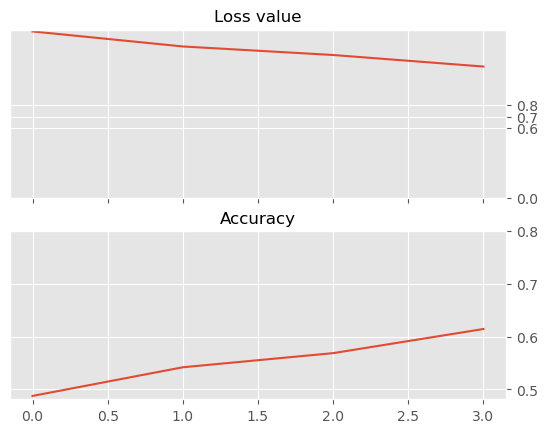

In [13]:
# plot the result
# import pandas as pd
records = pd.read_csv(modelname+'.csv')
plt.figure()
plt.subplot(211)
plt.plot(records['val_loss'])
plt.yticks([0.00,0.60,0.70,0.80])
plt.title('Loss value',fontsize=12)
ax = plt.gca()
ax.set_xticklabels([])
plt.subplot(212)
#plt.plot(records['val_acc'])
plt.plot(records['val_accuracy'])
#plt.plot(records.get('val_accuracy', records.get('val_acc')))
plt.yticks([0.5,0.6,0.7,0.8])
plt.title('Accuracy',fontsize=12)
plt.show()

# CNN

# ResNet


In [5]:
# =========================
# 1) Imports & Hyperparams
# =========================
# import tensorflow as tf                                         # core TF
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers       # Keras building blocks
from tensorflow.keras import initializers, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

num_classes   = 10                                              # CIFAR-10 classes
weight_decay  = 1e-4                                            # L2 strength used in convs/dense
dropout_rate  = 0.30                                            # moderate dropout inside residual units / head
base_filters  = 32                                              # width of the network (first stage)
batch_size    = 128                                             # efficient on GPUs
max_epochs    = 200                                             # upper bound; EarlyStopping will cut earlier
init          = initializers.HeNormal()                         # He initialization for ReLU-family activations
seed          = 42                                              # for reproducibility of augmentation shuffles


In [6]:
# =========================
# 1.1) Prepare Data
# =========================

from tensorflow.keras.utils import to_categorical
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)
# Assume you already have normalized arrays:
# X_train (45000,32,32,3), y_train_encoded (45000,10)
# X_valid (5000,32,32,3),  y_valid_encoded (5000,10)
# X_test  (10000,32,32,3), y_test_encoded  (10000,10)

AUTOTUNE = tf.data.AUTOTUNE # let TF pick good parallelism
batch_size = 256   # larger batch reduces Python overhead; adjust if RAM tight

# GPU-less but still fast: keras preprocessing layers run inside the TF graph i.e On-graph augmentation (runs inside TF, no GIL)
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),          # standard CIFAR-10 flip
    layers.RandomTranslation(0.1, 0.1),       # ±10% shifts
    layers.RandomZoom(0.1),                   # mild zoom
    layers.RandomRotation(0.05),              # small rotations
], name="augment")

# Assume X_train/X_valid/X_test are float32 in [0,1] and y_*_encoded are one-hot
ds_train = (tf.data.Dataset.from_tensor_slices((X_train, y_train_encoded))
            .shuffle(50_000, reshuffle_each_iteration=True)   # good mixing
            .batch(batch_size, drop_remainder=True)            # stable shapes
            .map(lambda x,y: (augment(x, training=True), y),   # GPU/CPU-friendly aug
                 num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))                               # overlap input & compute

ds_valid = (tf.data.Dataset.from_tensor_slices((X_valid, y_valid_encoded))
            .batch(512)                                        # larger eval batch
            .prefetch(AUTOTUNE))

ds_test  = (tf.data.Dataset.from_tensor_slices((X_test, y_test_encoded))
            .batch(512)
            .prefetch(AUTOTUNE))


(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)


In [15]:
# =========================================
# 2) Residual Block (Pre-activation ResNet)
#    - BN -> ReLU -> Conv -> BN -> ReLU -> (Dropout) -> Conv
#    - Projection shortcut when shape/stride changes
# =========================================
def residual_unit(inputs, filters, stride=1, name=None):
    """Pre-activation residual unit with optional downsampling."""
    x = layers.BatchNormalization(name=None if name is None else f"{name}_bn1")(inputs)   # normalize inputs to the block
    x = layers.ReLU(name=None if name is None else f"{name}_relu1")(x)                    # non-linearity before conv
    # Projection shortcut if spatial size or channel depth must change
    if stride != 1 or inputs.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, kernel_size=1, strides=stride, padding="same", use_bias=False,
            kernel_initializer=init, kernel_regularizer=regularizers.l2(weight_decay),
            name=None if name is None else f"{name}_proj"
        )(x)                                                                              # 1x1 conv to match (H,W,C)
    else:
        shortcut = inputs                                                                  # identity shortcut

    # First 3x3 conv (may downsample via stride)
    x = layers.Conv2D(
        filters, kernel_size=3, strides=stride, padding="same", use_bias=False,
        kernel_initializer=init, kernel_regularizer=regularizers.l2(weight_decay),
        name=None if name is None else f"{name}_conv1"
    )(x)

    x = layers.BatchNormalization(name=None if name is None else f"{name}_bn2")(x)        # normalize again
    x = layers.ReLU(name=None if name is None else f"{name}_relu2")(x)                    # non-linearity

    x = layers.Dropout(dropout_rate, name=None if name is None else f"{name}_drop")(x)    # regularize features

    # Second 3x3 conv (no downsampling here)
    x = layers.Conv2D(
        filters, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_initializer=init, kernel_regularizer=regularizers.l2(weight_decay),
        name=None if name is None else f"{name}_conv2"
    )(x)

    out = layers.Add(name=None if name is None else f"{name}_add")([x, shortcut])         # residual addition
    return out

In [18]:
#=============================================
# 3) ResNet Backbone (small, CIFAR-10-friendly)
#    Stages: 32 -> 64 -> 128 filters, with downsampling
#    Final: BN -> ReLU -> GAP -> Dropout -> Dense(softmax)
# =============================================
def build_resnet(input_shape=(32,32,3), n_blocks=(2,2,2)):
    """A compact pre-activation ResNet for CIFAR-10."""
    inputs = layers.Input(shape=input_shape, name="inputs")                               # (32,32,3)

    # Stem: a single 3x3 conv keeps CIFAR spatial size intact
    x = layers.Conv2D(
        base_filters, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_initializer=init, kernel_regularizer=regularizers.l2(weight_decay),
        name="stem_conv"
    )(inputs)                                                                             # (32,32,32)

    # Stage 1 (no downsampling, width = base_filters)
    for i in range(n_blocks[0]):
        x = residual_unit(x, filters=base_filters, stride=1, name=f"stage1_block{i+1}")   # keep (32,32)

    # Stage 2 (downsample to 16x16, width = 2*base_filters)
    x = residual_unit(x, filters=base_filters*2, stride=2, name="stage2_block1")          # (16,16,64)
    for i in range(1, n_blocks[1]):
        x = residual_unit(x, filters=base_filters*2, stride=1, name=f"stage2_block{i+1}") # keep (16,16)

    # Stage 3 (downsample to 8x8, width = 4*base_filters)
    x = residual_unit(x, filters=base_filters*4, stride=2, name="stage3_block1")          # (8,8,128)
    for i in range(1, n_blocks[2]):
        x = residual_unit(x, filters=base_filters*4, stride=1, name=f"stage3_block{i+1}") # keep (8,8)

    # Head: final BN+ReLU improves pre-activation design
    x = layers.BatchNormalization(name="head_bn")(x)                                      # normalize last feature map
    x = layers.ReLU(name="head_relu")(x)                                                  # non-linearity
    x = layers.GlobalAveragePooling2D(name="gap")(x)                                      # average over 8x8 -> (128,)
    x = layers.Dropout(dropout_rate, name="head_drop")(x)                                 # additional regularization
    outputs = layers.Dense(
        num_classes, activation="softmax", kernel_initializer=init,
        kernel_regularizer=regularizers.l2(weight_decay), name="predictions"
    )(x)                                                                                  # (10,)

    model = models.Model(inputs, outputs, name="ResNet_CIFAR10")                          # build the Model object

    # Optimizer: Adam is robust; we keep L2 in layers (not AdamW) to avoid double weight decay
    opt = optimizers.Adam(learning_rate=1e-3)                                             # start LR (ReduceLROnPlateau will tune)

    model.compile(
        optimizer=opt,                                                                     # optimizer
        loss="categorical_crossentropy",                                                   # one-hot labels
        metrics=["accuracy"]                                                               # monitor accuracy
    )
    return model


In [19]:
# ===========================
# 4) Data Augmentation (Numpy)
#    We use only geometric/intensity transforms since arrays are pre-normalized
# ===========================
augment = ImageDataGenerator(
    rotation_range=10,                               # small rotations
    width_shift_range=0.1, height_shift_range=0.1,   # random translations (±10%)
    zoom_range=0.1,                                  # mild zoom
    horizontal_flip=True,                            # standard for CIFAR-10
    fill_mode="reflect"                              # natural-looking fill for shifts/rotations
    # no rescale here; assume X_* already normalized
)

# Create augmented generator from arrays (shuffled each epoch)
train_gen = augment.flow(
    X_train, y_train_encoded,                        # arrays you already have
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)


In [9]:
# =================
# 5) Callbacks
# =================
ckpt = callbacks.ModelCheckpoint(
    "resnet_cifar10.keras",                          # save complete model (arch + weights)
    monitor="val_accuracy",                          # track validation accuracy
    save_best_only=True,                             # keep only the best epoch
    mode="max", verbose=1
)

early = callbacks.EarlyStopping(
    monitor="val_accuracy",                          # stop if val acc stalls
    patience=12,                                     # generous patience for ResNets + augmentation
    min_delta=0.001,                                 # require ≥0.1 pp improvement to reset patience
    restore_best_weights=True,                       # roll back to best epoch automatically
    verbose=1
)

reduce = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",                          # reduce LR on plateau
    factor=0.5,                                      # halve LR
    patience=5,                                      # wait 5 epochs without improvement
    min_lr=1e-6,                                     # floor
    verbose=1
)

csv = callbacks.CSVLogger("resnet_cifar10_log.csv", append=False)  # log per-epoch metrics to CSV

callbacks_list = [ckpt, early, reduce, csv]                        # bundle callbacks


In [ ]:
# ===========================
# 6) Build, Train, Evaluate
# ===========================
model = build_resnet(input_shape=(32,32,3), n_blocks=(2,2,2))      # small ResNet: 2 blocks per stage
model.summary()                                                    # print parameter count and shapes

history = model.fit(
    train_gen,                                                     # augmented batches
    epochs=max_epochs,                                             # upper limit; ES will cut earlier
    validation_data=(X_valid, y_valid_encoded),                    # no augmentation on validation
    callbacks=callbacks_list,                                      # ckpt, early stop, lr scheduler, csv
    verbose=2                                                      # one line per epoch (SSH-friendly)
)

# Evaluate the best model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test_encoded, verbose=2)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


Model: "ResNet_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ inputs[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │      9,216 │ stage1_block1_re… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        128 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_drop  │ (None, 32, 32,    │          0 │ stage1_block1_re… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │      9,216 │ stage1_block1_dr… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_co… │
│ (Add)               │ 32)               │            │ stem_conv[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 32, 32,    │        128 │ stage1_block1_ad… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 32, 32,    │      9,216 │ stage1_block2_re… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 32, 32,    │        128 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu2 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_drop  │ (None, 32, 32,    │          0 │ stage1_block2_re… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 32, 32,    │      9,216 │ stage1_block2_dr… │
│ (Conv2D)            │ 32)               │            │                 

 Total params: 698,090 (2.66 MB)

 Trainable params: 696,234 (2.66 MB)

 Non-trainable params: 1,856 (7.25 KB)

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200

Epoch 1: val_accuracy improved from None to 0.43680, saving model to resnet_cifar10.keras
352/352 - 247s - 703ms/step - accuracy: 0.4126 - loss: 1.8055 - val_accuracy: 0.4368 - val_loss: 2.3026 - learning_rate: 1.0000e-03
Epoch 2/200

Epoch 2: val_accuracy improved from 0.43680 to 0.62520, saving model to resnet_cifar10.keras
352/352 - 243s - 690ms/step - accuracy: 0.5783 - loss: 1.3800 - val_accuracy: 0.6252 - val_loss: 1.3004 - learning_rate: 1.0000e-03
Epoch 3/200

Epoch 3: val_accuracy improved from 0.62520 to 0.65640, saving model to resnet_cifar10.keras
352/352 - 232s - 658ms/step - accuracy: 0.6403 - loss: 1.2065 - val_accuracy: 0.6564 - val_loss: 1.2066 - learning_rate: 1.0000e-03
Epoch 4/200

Epoch 4: val_accuracy did not improve from 0.65640
352/352 - 224s - 636ms/step - accuracy: 0.6838 - loss: 1.0880 - val_accuracy: 0.6466 - val_loss: 1.1756 - learning_rate: 1.0000e-03
Epoch 5/200

Epoch 5: val_accuracy improved from 0.65640 to 0.69740, saving model to resnet_c

In [ ]:
# ============================
# Load saved model and continue fitting
# ============================
from tensorflow.keras.models import load_model

model = load_model("resnet_cifar10.keras")     # loads architecture + weights + optimizer state
# If you want to resume training: callbacks as before, then:
history = model.fit(
    ds_train,                                   # use tf.data pipeline
    validation_data=ds_valid,
    epochs=200,                                 # upper bound; EarlyStopping will cut earlier
    callbacks=callbacks_list,                   # your checkpoint/early/lr/csv bundle
    verbose=2
)


test_loss, test_acc = model.evaluate(ds_test, verbose=2)  # fast batched eval
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

Epoch 1/200

Epoch 1: val_accuracy improved from None to 0.81080, saving model to resnet_cifar10.keras
175/175 - 202s - 1s/step - accuracy: 0.8145 - loss: 0.7204 - val_accuracy: 0.8108 - val_loss: 0.7305 - learning_rate: 1.0000e-03
Epoch 2/200

Epoch 2: val_accuracy did not improve from 0.81080
175/175 - 190s - 1s/step - accuracy: 0.8209 - loss: 0.7024 - val_accuracy: 0.7738 - val_loss: 0.8866 - learning_rate: 1.0000e-03
Epoch 3/200

Epoch 3: val_accuracy did not improve from 0.81080
175/175 - 191s - 1s/step - accuracy: 0.8224 - loss: 0.6904 - val_accuracy: 0.7744 - val_loss: 0.8580 - learning_rate: 1.0000e-03
Epoch 4/200

Epoch 4: val_accuracy did not improve from 0.81080
175/175 - 192s - 1s/step - accuracy: 0.8250 - loss: 0.6789 - val_accuracy: 0.7958 - val_loss: 0.7854 - learning_rate: 1.0000e-03
Epoch 5/200

Epoch 5: val_accuracy improved from 0.81080 to 0.82780, saving model to resnet_cifar10.keras
175/175 - 192s - 1s/step - accuracy: 0.8274 - loss: 0.6719 - val_accuracy: 0.8278 -

In [7]:
from tensorflow.keras.models import load_model

model = load_model("resnet_cifar10.keras")     # loads architecture + weights + optimizer state
test_loss, test_acc = model.evaluate(ds_test, verbose=2)  # fast batched eval
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

20/20 - 4s - 223ms/step - accuracy: 0.8846 - loss: 0.4854
Test accuracy: 0.8846 | Test loss: 0.4854


# Transformer (Encoders only)

# CNN followed by Transformer Encoders